<a href="https://colab.research.google.com/github/juan-alberto-garcia/baile/blob/master/Projecto_Busqueda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reporte Final: Proyecto de Búsqueda Box Pusher
**Alumno:** Juan Alberto García Chavez

**Equipo:** IDK

**Materia:** Inteligencia Artificial  
**Repositorio:** https://github.com/juan-alberto-garcia/baile  

---

## 1. Introducción
El objetivo de este proyecto es implementar y evaluar algoritmos de búsqueda no informada e informada aplicados a problemas clásicos de IA, específicamente el juego de **Sokoban (Box Pusher)**.

En este reporte se documenta la formulación del problema, la definición de los estados, el diseño de la función heurística basada en la distancia Manhattan y la ejecución del algoritmo de búsqueda **A* ($A^*$ Search)**.

In [17]:

import heapq
import matplotlib.pyplot as plt

# Clase para representar cada nodo del árbol de búsqueda
class node:
    def __init__(self, state, depth=0, parent=None, action=None):
        self.state = state     # Estado: ((jugador_y, jugador_x), ((caja_y, caja_x),))
        self.depth = depth     # Costo acumulado g(n): número de pasos
        self.parent = parent   # Nodo padre para reconstruir el camino
        self.action = action   # Descripción de la acción realizada

# Algoritmo de Búsqueda Informada A*
class TreeSearch:
    def __init__(self, start_node, successor_fn, goal_fn, strategy="a*", heuristic=None):
        self.start_node = start_node
        self.successor_fn = successor_fn
        self.goal_fn = goal_fn
        self.strategy = strategy
        self.heuristic = heuristic
        self.iterations = 0

    def find(self):
        frontier = []
        count = 0
        h_val = self.heuristic(self.start_node) if self.heuristic else 0
        f_val = self.start_node.depth + h_val  # f(n) = g(n) + h(n)

        heapq.heappush(frontier, (f_val, count, self.start_node))
        visited = set()

        while frontier:
            self.iterations += 1
            _, _, current = heapq.heappop(frontier)

            if current.state in visited:
                continue
            visited.add(current.state)

            if self.goal_fn(current):
                return current

            for succ in self.successor_fn(current):
                if succ.state not in visited:
                    count += 1
                    h_succ = self.heuristic(succ) if self.heuristic else 0
                    f_succ = succ.depth + h_succ
                    heapq.heappush(frontier, (f_succ, count, succ))

        return None

## 2. Formulación del Problema

Para resolver Sokoban mediante búsqueda en espacio de estados, el problema se modela de la siguiente manera:

* **Estado ($S$):** Representado por la tupla `(jugador, cajas)`, donde:
  * `jugador`: Coordenada $(r, c)$ de la posición del personaje.
  * `cajas`: Tupla ordenada de coordenadas de cada caja en el tablero.
* **Acciones:** Movimientos discretos en cuatro direcciones: $\text{Arriba} (-1,0)$, $\text{Abajo} (1,0)$, $\text{Izquierda} (0,-1)$, $\text{Derecha} (0,1)$.
* **Transición de Estado:**
  * Un movimiento es válido si la celda destino no es una pared.
  * Si la celda contiene una caja, la acción solo es válida si la celda posterior a la caja está libre (sin pared ni otra caja).
* **Estado Meta:** El problema se resuelve cuando la posición de todas las cajas coincide con el conjunto de coordenadas de las metas ($G$).

In [18]:
# Definición del mapa 5x5 rodeado por paredes
paredes = {
    (0,0), (0,1), (0,2), (0,3), (0,4),
    (1,0),                            (1,4),
    (2,0),                            (2,4),
    (3,0),                            (3,4),
    (4,0), (4,1), (4,2), (4,3), (4,4)
}

metas = ((3, 3),)
jugador_inicio = (1, 1)
caja_inicio = ((2, 2),)

# Estado inicial: (posicion_jugador, tupla_de_cajas)
nodo_inicial = node((jugador_inicio, caja_inicio), depth=0)

# Genera los siguientes estados válidos aplicando las reglas de Sokoban
def sucesor_box_pusher(nodo):
    jugador, cajas = nodo.state
    cajas_set = set(cajas)
    movimientos = [(-1, 0, "Arriba"), (1, 0, "Abajo"), (0, -1, "Izquierda"), (0, 1, "Derecha")]
    sucesores = []

    for dr, dc, nombre in movimientos:
        nuevo_jugador = (jugador[0] + dr, jugador[1] + dc)

        # 1. Regla: Colisión contra pared
        if nuevo_jugador in paredes:
            continue

        # 2. Regla: Empuje de caja
        if nuevo_jugador in cajas_set:
            nueva_caja = (nuevo_jugador[0] + dr, nuevo_jugador[1] + dc)
            # No se puede empujar si detrás hay pared u otra caja
            if nueva_caja in paredes or nueva_caja in cajas_set:
                continue

            nuevas_cajas = tuple(sorted([c if c != nuevo_jugador else nueva_caja for c in cajas]))
            sucesores.append(node((nuevo_jugador, nuevas_cajas), depth=nodo.depth + 1, parent=nodo, action=f"Empujar {nombre}"))

        # 3. Regla: Movimiento a casilla libre
        else:
            sucesores.append(node((nuevo_jugador, cajas), depth=nodo.depth + 1, parent=nodo, action=f"Mover {nombre}"))

    return sucesores

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_sokoban(state, titulo="", grid_size=(5, 5)):
    jugador, cajas = state
    fig, ax = plt.subplots(figsize=(4, 4))

    # 1. Dibujar el mapa base (Paredes, Meta con Bandera y Suelo)
    for r in range(grid_size[0]):
        for c in range(grid_size[1]):
            if (r, c) in paredes:
                # PARED: Bloque gris con textura
                wall = patches.Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#4A4A4A', edgecolor='#333333', linewidth=1.5)
                ax.add_patch(wall)
                wall_hatch = patches.Rectangle((c-0.5, r-0.5), 1, 1, fill=False, hatch='//', edgecolor='#666666', linewidth=0.5)
                ax.add_patch(wall_hatch)

            elif (r, c) in metas:
                # META: Fondo verde claro
                bg = patches.Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#D4EDDA', edgecolor='#28A745', linewidth=1.5)
                ax.add_patch(bg)

                # Astil / Mástil de la bandera
                ax.plot([c - 0.22, c - 0.22], [r + 0.32, r - 0.32], color='#222222', linewidth=3)

                # Cuadrícula a cuadros de la bandera de llegada (🏁)
                rows, cols = 3, 4
                fw, fh = 0.45 / cols, 0.32 / rows
                x_start, y_start = c - 0.22, r - 0.32
                for i in range(rows):
                    for j in range(cols):
                        color = '#222222' if (i + j) % 2 == 0 else '#FFFFFF'
                        sq = patches.Rectangle((x_start + j*fw, y_start + i*fh), fw, fh, facecolor=color, edgecolor='#666666', linewidth=0.3)
                        ax.add_patch(sq)

            else:
                # SUELO LIBRE
                bg = patches.Rectangle((c-0.5, r-0.5), 1, 1, facecolor='#F8F9FA', edgecolor='#DEE2E6')
                ax.add_patch(bg)

    # 2. Dibujar Cajas (Caja de madera café con refuerzo)
    for b in cajas:
        bx, by = b[1], b[0]
        box = patches.FancyBboxPatch((bx-0.35, by-0.35), 0.7, 0.7,
                                      boxstyle="round,pad=0.02,rounding_size=0.08",
                                      facecolor='#D9822B', edgecolor='#8A4B08', linewidth=2)
        ax.add_patch(box)
        ax.plot([bx-0.25, bx+0.25], [by-0.25, by+0.25], color='#8A4B08', linewidth=1.5)
        ax.plot([bx-0.25, bx+0.25], [by+0.25, by-0.25], color='#8A4B08', linewidth=1.5)

    # 3. Dibujar Jugador (Personaje azul con ojos)
    px, py = jugador[1], jugador[0]
    player = patches.Circle((px, py), 0.32, facecolor='#007BFF', edgecolor='#004085', linewidth=2)
    ax.add_patch(player)
    eye1 = patches.Circle((px-0.1, py-0.08), 0.06, facecolor='white')
    eye2 = patches.Circle((px+0.1, py-0.08), 0.06, facecolor='white')
    pupil1 = patches.Circle((px-0.1, py-0.08), 0.03, facecolor='black')
    pupil2 = patches.Circle((px+0.1, py-0.08), 0.03, facecolor='black')
    ax.add_patch(eye1)
    ax.add_patch(eye2)
    ax.add_patch(pupil1)
    ax.add_patch(pupil2)

    # Configuración del tablero
    ax.set_xticks(range(grid_size[1]))
    ax.set_yticks(range(grid_size[0]))
    ax.set_xlim(-0.5, grid_size[1]-0.5)
    ax.set_ylim(-0.5, grid_size[0]-0.5)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    plt.title(titulo, fontsize=11, fontweight='bold')
    plt.show()

## 3. Algoritmo de Búsqueda y Heurística

Para garantizar encontrar la solución de menor número de pasos en el menor tiempo de cómputo posible, se utiliza el algoritmo **A***.

### Heurística de Manhattan
El algoritmo $A^*$ evalúa cada nodo mediante la función de evaluación:
$$f(n) = g(n) + h(n)$$

Donde $g(n)$ es el costo acumulado de pasos desde el inicio, y $h(n)$ es la **distancia Manhattan** acumulada de cada caja hacia su meta más cercana:

$$h(n) = \sum_{c \in Cages} \min_{m \in Metas} (\vert{}r_c - r_m\vert{} + \vert{}c_c - c_m\vert{})$$

* **Admisibilidad:** Esta heurística es admisible porque nunca sobreestima el costo real para llevar las cajas a las metas (no contempla obstáculos adicionales como paredes).

=== RESULTADOS ===
Pasos de la solución: 5
Iteraciones realizadas: 28

Paso 0: Estado Inicial -> Posición: ((1, 1), ((2, 2),))


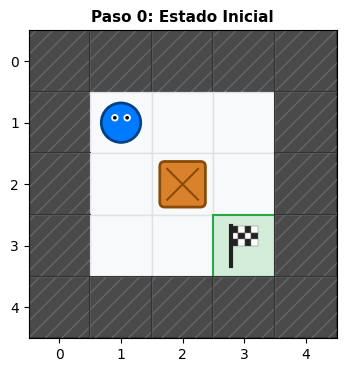

Paso 1: Mover Abajo -> Posición: ((2, 1), ((2, 2),))


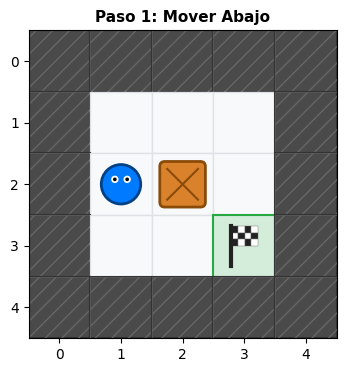

Paso 2: Empujar Derecha -> Posición: ((2, 2), ((2, 3),))


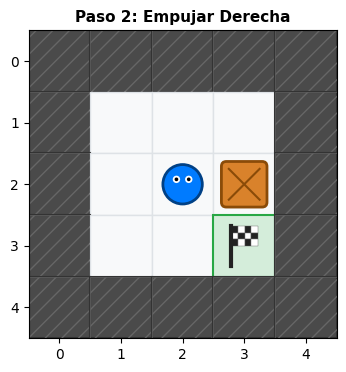

Paso 3: Mover Arriba -> Posición: ((1, 2), ((2, 3),))


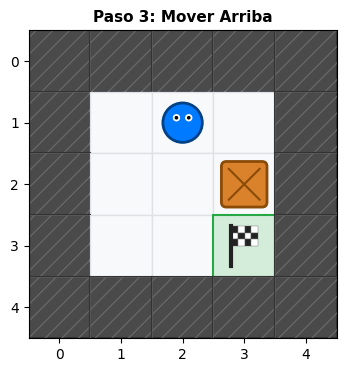

Paso 4: Mover Derecha -> Posición: ((1, 3), ((2, 3),))


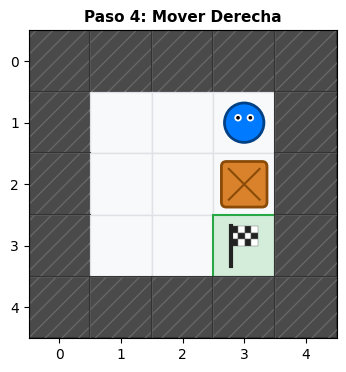

Paso 5: Empujar Abajo -> Posición: ((2, 3), ((3, 3),))


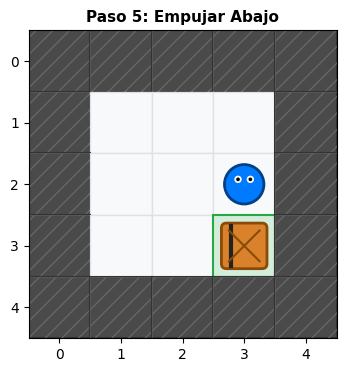

In [20]:
# 1. Ejecución del algoritmo A*
buscador = TreeSearch(nodo_inicial, sucesor_box_pusher, es_meta, strategy="a*", heuristic=heuristica_manhattan)
solucion = buscador.find()

# 2. Reconstrucción de la ruta desde la meta hasta el inicio
camino = []
actual = solucion
while actual:
    camino.append(actual)
    actual = actual.parent
camino.reverse()

# 3. Impresión de métricas y visualización paso a paso
print(f"=== RESULTADOS ===")
print(f"Pasos de la solución: {len(camino) - 1}")
print(f"Iteraciones realizadas: {buscador.iterations}\n")

for i, n in enumerate(camino):
    accion_txt = n.action if n.action else "Estado Inicial"
    print(f"Paso {i}: {accion_txt} -> Posición: {n.state}")
    plot_sokoban(n.state, titulo=f"Paso {i}: {accion_txt}")

## 4. Resultados y Conclusiones

* **Rendimiento:** El algoritmo $A^*$ junto con la heurística Manhattan logra encontrar el camino óptimo hacia la meta explorando una cantidad de estados significativamente menor en comparación con algoritmos no informados como BFS.
* **Visualización:** Se implementó una representación visual en 2D utilizando `matplotlib`, sustituyendo texto plano por sprites geométricos para el personaje, las cajas de madera y la bandera de llegada.
* **Conclusión:** La correcta abstracción del estado e inmunidad a ciclos mediante la estructura de nodos fue clave para resolver el problema sin caer en recursiones infinitas o bloqueos (deadlocks).